In [61]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
%matplotlib inline

In [62]:
words = open('names.txt', 'r').read().splitlines()
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [63]:
chars = sorted(list(set(''.join(words))))
stoi = {j:i + 1 for i,j in enumerate(chars)}
stoi['.'] = 0
itos = {j:i for i,j in stoi.items()}
vocab_size = len(itos)

In [64]:
import random
block_size = 3

def build_data(words):
    
    x = []
    y = []

    for word in words:
        context = [0] * block_size

        for ch in word + '.':
            x.append(context)
            y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]

    x = torch.tensor(x)
    y = torch.tensor(y)

    print(x.shape, y.shape)
    return x,y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

x_train, y_train = build_data(words[:n1])
x_val, y_val = build_data(words[n1:n2])
x_test, y_test = build_data(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [65]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g)
b1 = torch.randn(n_hidden, generator = g)
w2 = torch.randn((n_hidden, vocab_size), generator = g)
b2 = torch.randn(vocab_size, generator = g)
parameters = [C, w1, b1, w2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15032


In [66]:
steps = 100000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    h = torch.tanh((emb.view(-1, 45)) @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  100000 : 28.0290
  10000 /  100000 : 2.4032
  20000 /  100000 : 2.1263
  30000 /  100000 : 2.2085
  40000 /  100000 : 2.3381
  50000 /  100000 : 2.1703
  60000 /  100000 : 2.0565
  70000 /  100000 : 2.1845
  80000 /  100000 : 1.9740
  90000 /  100000 : 2.0939


In [67]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    h = torch.tanh((emb.view(-1, 45)) @ w1 + b1)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.1202800273895264
2.164646863937378


In [68]:
g = torch.Generator().manual_seed(2147483647 + 5)

for i in range(30):

    ix = 0
    name = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ w1 + b1)
        logits = h @ w2 + b2
        p = F.softmax(logits, dim=1)

        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))

treef
eliz
gaviel
deylah
mela
shune
sorvor
jamovin
kylynn
chi
bodethyne
jmlda
esa
casshembyn
kiule
yura
miccelyan
alikahyana
sof
noa
antles
granvi
brys
rose
khida
lar
shaniyan
yana
mkaylan
disa


In [84]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * 0.2
b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0
parameters = [C, w1, b1, w2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15032


In [85]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

    break

      0 /  200000 : 3.3237


In [73]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.0081210136413574
2.089632987976074


In [74]:
g = torch.Generator().manual_seed(2147483647 + 5)

for i in range(30):

    ix = 0
    name = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(emb.shape[0], -1)
        h_preact = embcat @ w1 + b1
        h = torch.tanh(h_preact)
        logits = h @ w2 + b2
        p = F.softmax(logits, dim=1)

        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))

treigh
day
gawlen
deylah
lin
grayleannextyn
jayzlyndy
zita
med
jakydustaljh
abdu
ahira
kelza
kitai
yure
michany
raedriano
regor
arsal
lulen
grastia
tys
rose
khia
glan
sia
mylias
jahmiese
quenlee
zola


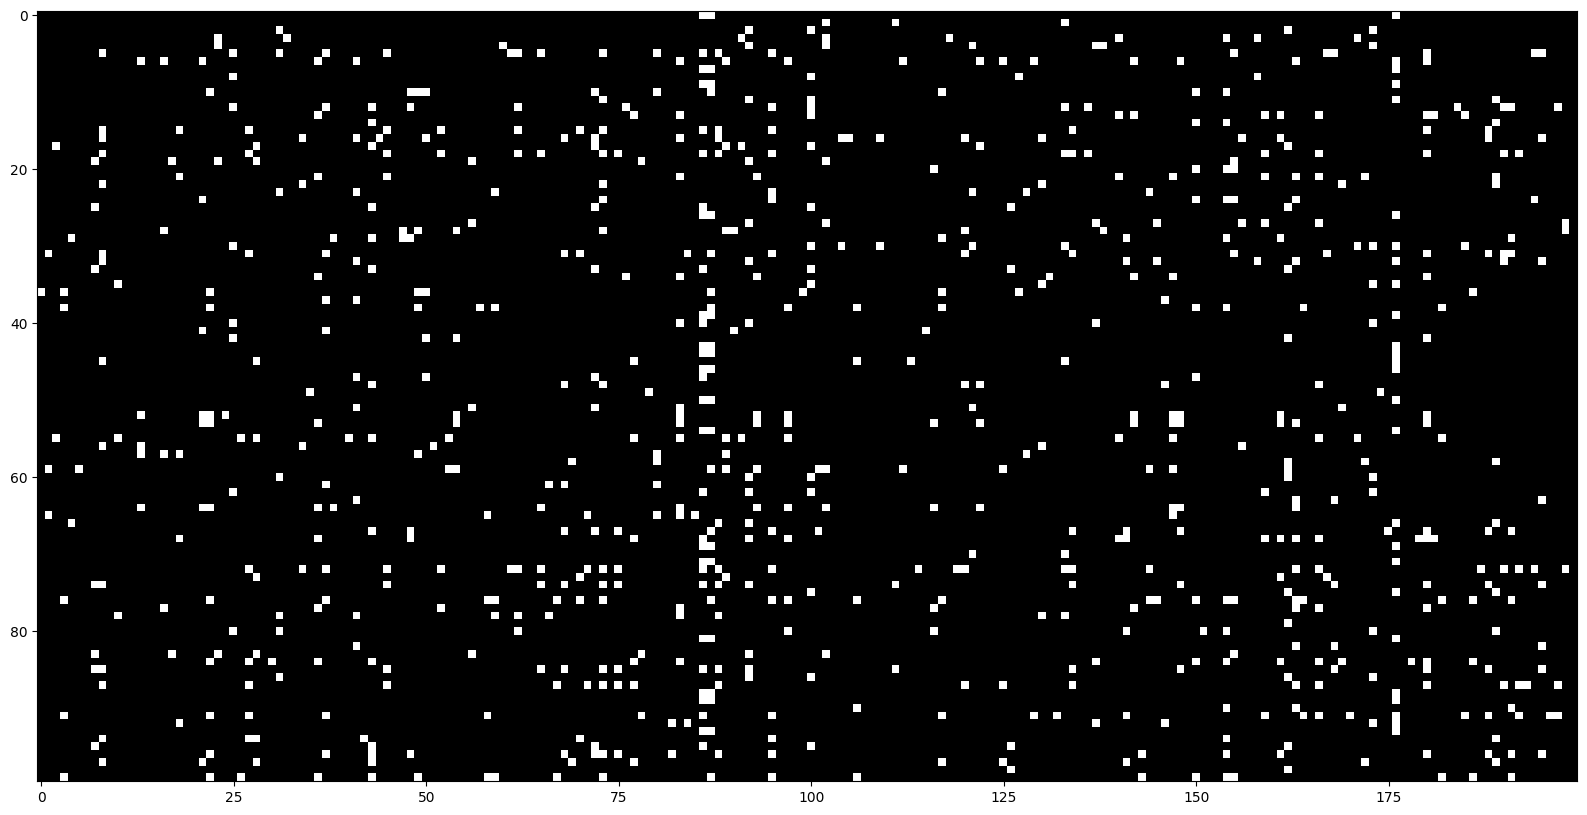

In [86]:
plt.figure(figsize = (20, 10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation='nearest')

(array([1248.,  853.,  785.,  510.,  454.,  448.,  464.,  406.,  328.,
         310.,  322.,  378.,  296.,  297.,  259.,  266.,  295.,  336.,
         192.,  312.,  249.,  268.,  265.,  252.,  264.,  326.,  180.,
         235.,  261.,  251.,  258.,  244.,  281.,  251.,  248.,  370.,
         331.,  278.,  300.,  291.,  304.,  403.,  423.,  378.,  466.,
         556.,  557.,  626.,  815., 1310.]),
 array([-9.99967575e-01, -9.59968688e-01, -9.19969802e-01, -8.79970915e-01,
        -8.39972029e-01, -7.99973142e-01, -7.59974256e-01, -7.19975369e-01,
        -6.79976482e-01, -6.39977596e-01, -5.99978709e-01, -5.59979823e-01,
        -5.19980936e-01, -4.79982049e-01, -4.39983163e-01, -3.99984276e-01,
        -3.59985390e-01, -3.19986503e-01, -2.79987617e-01, -2.39988730e-01,
        -1.99989843e-01, -1.59990957e-01, -1.19992070e-01, -7.99931836e-02,
        -3.99942970e-02,  4.58955765e-06,  4.00034761e-02,  8.00023627e-02,
         1.20001249e-01,  1.60000136e-01,  1.99999022e-01,  2.399979

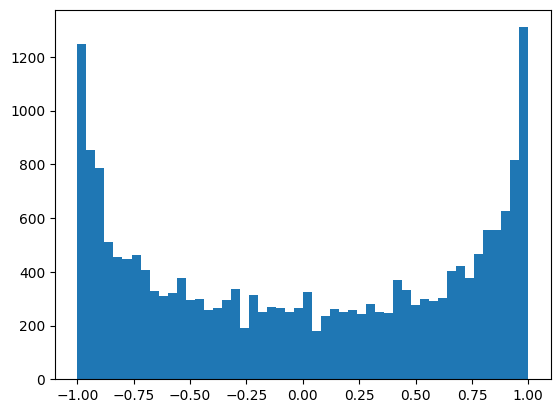

In [89]:
plt.hist(h.view(-1).tolist(), 50)

(array([2.000e+00, 0.000e+00, 3.000e+00, 3.000e+00, 6.000e+00, 1.100e+01,
        1.400e+01, 2.500e+01, 6.000e+01, 5.600e+01, 7.900e+01, 9.200e+01,
        1.370e+02, 2.200e+02, 2.470e+02, 3.150e+02, 5.420e+02, 7.120e+02,
        7.400e+02, 8.530e+02, 1.158e+03, 1.149e+03, 1.269e+03, 1.429e+03,
        1.489e+03, 1.310e+03, 1.426e+03, 1.111e+03, 1.148e+03, 1.012e+03,
        7.910e+02, 6.550e+02, 4.710e+02, 4.110e+02, 2.960e+02, 2.480e+02,
        1.910e+02, 8.600e+01, 8.700e+01, 5.300e+01, 3.100e+01, 2.000e+01,
        1.500e+01, 1.100e+01, 7.000e+00, 4.000e+00, 4.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([-5.51519966, -5.29128183, -5.06736401, -4.84344618, -4.61952835,
        -4.39561052, -4.1716927 , -3.94777487, -3.72385704, -3.49993921,
        -3.27602139, -3.05210356, -2.82818573, -2.6042679 , -2.38035007,
        -2.15643225, -1.93251442, -1.70859659, -1.48467876, -1.26076094,
        -1.03684311, -0.81292528, -0.58900745, -0.36508963, -0.1411718 ,
         0.

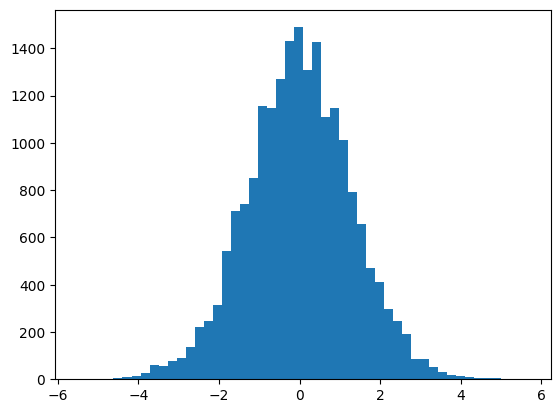

In [88]:
plt.hist(h_preact.view(-1).tolist(), 50)

tensor(0.0192) tensor(1.0042)
tensor(-0.0089) tensor(9.9346)


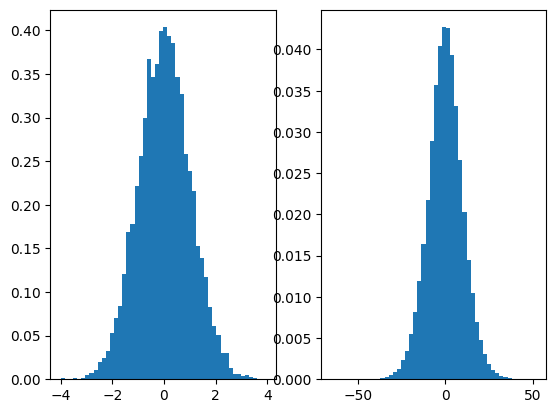

In [103]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * (10 ** 0.5)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True);

In [105]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * (5 / 3) / (n_emb * block_size) ** 0.5 #0.2
b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0
parameters = [C, w1, b1, w2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15032


In [107]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  200000 : 3.2015
  10000 /  200000 : 2.1120
  20000 /  200000 : 2.0810
  30000 /  200000 : 2.0022
  40000 /  200000 : 2.0972
  50000 /  200000 : 1.7474
  60000 /  200000 : 1.8273
  70000 /  200000 : 1.9147
  80000 /  200000 : 2.1583
  90000 /  200000 : 2.1999
 100000 /  200000 : 2.1771
 110000 /  200000 : 2.0228
 120000 /  200000 : 2.1516
 130000 /  200000 : 2.0792
 140000 /  200000 : 1.9579
 150000 /  200000 : 1.9389
 160000 /  200000 : 1.8173
 170000 /  200000 : 1.9519
 180000 /  200000 : 1.9106
 190000 /  200000 : 1.7998


In [108]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.012070417404175
2.091547727584839


## Batch Normalization

In [109]:
h_preact.shape

torch.Size([100, 200])

In [113]:
print(h_preact.mean(0, keepdim=True).shape)
print(h_preact.std(0, keepdim=True).shape)

torch.Size([1, 200])
torch.Size([1, 200])


In [114]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * (5 / 3) / (n_emb * block_size) ** 0.5 #0.2
b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0
parameters = [C, w1, b1, w2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15032


In [115]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = (h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  200000 : 3.2961
  10000 /  200000 : 2.0277
  20000 /  200000 : 2.2078
  30000 /  200000 : 2.1108
  40000 /  200000 : 2.2101
  50000 /  200000 : 2.0396
  60000 /  200000 : 2.2609
  70000 /  200000 : 2.2151
  80000 /  200000 : 1.8939
  90000 /  200000 : 2.0484
 100000 /  200000 : 1.9821
 110000 /  200000 : 1.8907
 120000 /  200000 : 2.0628
 130000 /  200000 : 1.8755
 140000 /  200000 : 1.9964
 150000 /  200000 : 2.0589
 160000 /  200000 : 1.8809
 170000 /  200000 : 1.9453
 180000 /  200000 : 2.0333
 190000 /  200000 : 2.0308


In [116]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = (h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.046359062194824
2.0941882133483887


## Gain and bias in batch normalization

In [118]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * (5 / 3) / (n_emb * block_size) ** 0.5
b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0

bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))

parameters = [C, w1, b1, w2, b2, bn_bias, bn_gain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15432


In [119]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = bn_gain * ((h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)) + bn_bias
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  200000 : 3.2931
  10000 /  200000 : 2.0689
  20000 /  200000 : 2.2779
  30000 /  200000 : 1.9661
  40000 /  200000 : 2.1127
  50000 /  200000 : 2.1918
  60000 /  200000 : 1.9804
  70000 /  200000 : 1.9054
  80000 /  200000 : 1.8856
  90000 /  200000 : 1.9220
 100000 /  200000 : 2.0384
 110000 /  200000 : 1.8876
 120000 /  200000 : 2.0742
 130000 /  200000 : 2.0432
 140000 /  200000 : 2.0688
 150000 /  200000 : 2.1673
 160000 /  200000 : 2.1183
 170000 /  200000 : 2.0460
 180000 /  200000 : 1.9911
 190000 /  200000 : 1.9638


In [121]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = bn_gain * ((h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)) + bn_bias
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.026716470718384
2.087524890899658


## Fixed mean and standard deviation
cuz during sampling there's only one input, so mean and std can't be calculated

In [122]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * (5 / 3) / (n_emb * block_size) ** 0.5
b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0

bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))

parameters = [C, w1, b1, w2, b2, bn_bias, bn_gain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15432


In [123]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = bn_gain * ((h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)) + bn_bias
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  200000 : 3.2942
  10000 /  200000 : 2.2182
  20000 /  200000 : 2.0073
  30000 /  200000 : 2.0841
  40000 /  200000 : 1.9278
  50000 /  200000 : 2.1116
  60000 /  200000 : 2.2064
  70000 /  200000 : 2.0394
  80000 /  200000 : 2.0593
  90000 /  200000 : 2.2270
 100000 /  200000 : 1.9255
 110000 /  200000 : 2.2409
 120000 /  200000 : 1.9387
 130000 /  200000 : 2.1525
 140000 /  200000 : 1.8860
 150000 /  200000 : 1.8489
 160000 /  200000 : 2.0774
 170000 /  200000 : 2.1429
 180000 /  200000 : 2.0907
 190000 /  200000 : 2.1310


#### Calculation of mean and std for entire training set

In [125]:
with torch.no_grad():
    emb = C[x_train]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    bn_mean = h_preact.mean(0, keepdim=True)
    bn_std = h_preact.std(0, keepdim=True)

In [127]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 + b1
    h_preact = bn_gain * (h_preact - bn_mean) / bn_std + bn_bias
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.0269784927368164
2.090304374694824


## Running mean and std

bias b1 is removed here as it is anyway removed when bm_mean_i is subtracted from h_preact, so gradient of b1 would just become 0

In [143]:
n_emb = 15
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator = g)
w1 = torch.randn((n_emb * block_size, n_hidden), generator = g) * (5 / 3) / (n_emb * block_size) ** 0.5
# b1 = torch.randn(n_hidden, generator = g) * 0.01
w2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0

bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

parameters = [C, w1, w2, b2, bn_bias, bn_gain]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

15232


In [144]:
steps = 200000
batch_size = 100

for i in range(steps):
    # forward pass
    ix = torch.randint(0, x_train.shape[0], (batch_size,))

    emb = C[x_train[ix]]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 # + b1
    bn_mean_i = h_preact.mean(0, keepdim=True)
    bn_std_i = h_preact.std(0, keepdim=True)
    h_preact = bn_gain * ((h_preact - bn_mean_i) / bn_std_i) + bn_bias
    bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_mean_i
    bn_std_running = 0.999 * bn_std_running + 0.001 * bn_std_i
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_train[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d} / {steps:7d} : {loss.item():.4f}")

      0 /  200000 : 3.2994
  10000 /  200000 : 2.0120
  20000 /  200000 : 1.9986
  30000 /  200000 : 2.2019
  40000 /  200000 : 1.9430
  50000 /  200000 : 2.0443
  60000 /  200000 : 2.2812
  70000 /  200000 : 1.9943
  80000 /  200000 : 2.0798
  90000 /  200000 : 2.0309
 100000 /  200000 : 2.1387
 110000 /  200000 : 2.2694
 120000 /  200000 : 2.1460
 130000 /  200000 : 1.9775
 140000 /  200000 : 2.1847
 150000 /  200000 : 2.2135
 160000 /  200000 : 2.0234
 170000 /  200000 : 2.0324
 180000 /  200000 : 1.9088
 190000 /  200000 : 1.9346


In [ ]:
@torch.no_grad()
def split_data(split):
    x,y = {
        'train': (x_train, y_train),
        'val': (x_val, y_val),
        'test': (x_test, y_test),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ w1 # + b1
    h_preact = bn_gain * (h_preact - bn_mean_running) / bn_std_running + bn_bias
    h = torch.tanh(h_preact)
    logits = h @ w2 + b2
    l = F.cross_entropy(logits, y)
    print(l.item())

split_data('train')
split_data('val')

2.0266542434692383
2.0880353450775146


## Pytorchifying the code

In [ ]:
g = torch.Generator().manual_seed(2147483647)

class Linear:

    def __init__(self, in_features, out_features, bias = True):
        self.weights = torch.randn((in_features, out_features), generator = g) / in_features ** 0.5
        self.bias = torch.zeros(out_features) if bias else None

    def __call__(self, x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def __parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, num_features, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.alpha = torch.ones(num_features) # gain
        self.beta = torch.zeros(num_features) # bias
        # buffers
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            x_mean = x.mean(0, keepdim = True)
            x_var = x.var = 